In [1]:
# VAE pour prédiction de Time Series S&P 500

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.losses import mse
import tensorflow as tf

# 1. Chargement des données
sp500 = yf.download('^GSPC', start='2010-01-01', end='2025-01-01')
data = sp500[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

# 2. Normalisation
data_values = data.values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_values)

# 3. Construction des séquences
past_window = 30
future_window = 10
X, y = [], []
for i in range(len(data_scaled) - past_window - future_window):
    X.append(data_scaled[i:i+past_window])
    y.append(data_scaled[i+past_window:i+past_window+future_window])
X = np.array(X)
y = np.array(y)

# 4. Définition du VAE
latent_dim = 16
input_shape = X.shape[1:]

# Encodeur
encoder_inputs = Input(shape=input_shape)
x = layers.LSTM(64, return_sequences=False)(encoder_inputs)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Décodeur
decoder_inputs = Input(shape=(latent_dim,))
x = layers.RepeatVector(future_window)(decoder_inputs)
x = layers.LSTM(64, return_sequences=True)(x)
decoder_outputs = layers.TimeDistributed(layers.Dense(input_shape[1]))(x)
decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

# VAE Model
outputs = decoder(encoder(encoder_inputs)[2])
vae = Model(encoder_inputs, outputs, name='vae')

# Loss
reconstruction_loss = mse(y, outputs)
reconstruction_loss *= future_window * input_shape[1]
kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
kl_loss = tf.reduce_mean(tf.reduce_sum(-0.5 * kl_loss, axis=1))
vae_loss = tf.reduce_mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

# 5. Entraînement
vae.fit(X, y, epochs=50, batch_size=64, validation_split=0.1)

# 6. Prédiction et visualisation
encoded_data = encoder.predict(X[:1])[2]
predicted_sequence = decoder.predict(encoded_data)

# Réaffichage dans l'échelle originale
true_future = scaler.inverse_transform(y[0])
pred_future = scaler.inverse_transform(predicted_sequence[0])

plt.figure(figsize=(10, 4))
plt.plot(true_future[:, 3], label='True Close Price')
plt.plot(pred_future[:, 3], label='Predicted Close Price', linestyle='--')
plt.title('S&P 500 Close Price Prediction')
plt.xlabel('Days Ahead')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
2025-04-15 16:00:01.795812: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-04-15 16:00:01.795887: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-04-15 16:00:01.795898: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-04-15 16:00:01.796221: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-15 16:00:01.796235: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


# Livrable 2 :

In [1]:
import tensorflow as tf
import numpy as np
import os
import sys
from tensorflow import keras

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model_loader import ModelLoader
from src.data_loader import DataLoader
from src.utils import get_confusion_matrix, get_classification_report

print(tf.__version__)

2.16.2


## Généation du dataset de photos

In [2]:
data_loader = DataLoader()
train_ds, test_ds, val_ds = data_loader.load_unique_dataset(folder_name="Photo")


Photo Dataset size: 9993


2025-04-15 16:03:08.064590: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-04-15 16:03:08.064638: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-04-15 16:03:08.064646: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-04-15 16:03:08.064692: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-15 16:03:08.064748: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Bruitage du dataset

In [3]:
noisy_train_ds = data_loader.add_noise_to_dataset(train_ds)
noisy_val_ds = data_loader.add_noise_to_dataset(val_ds)

2025-04-15 16:03:12.128606: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


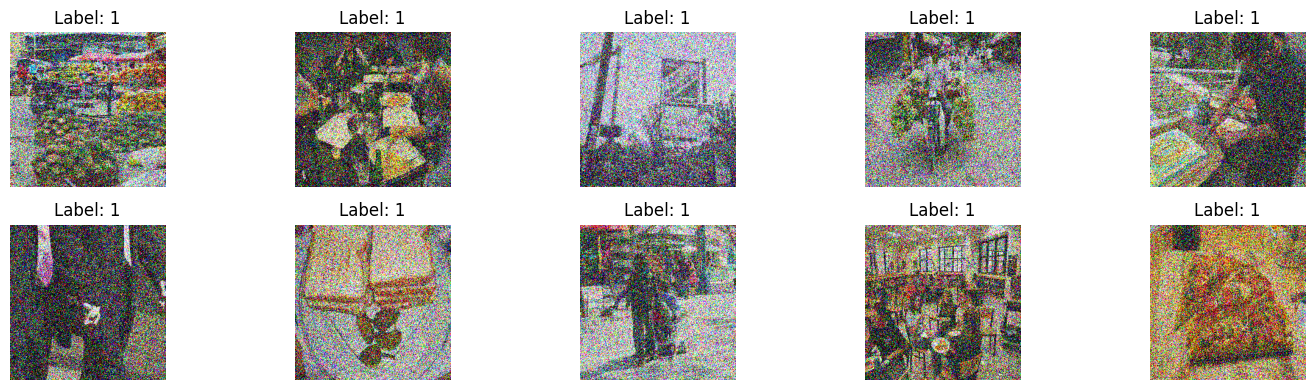

In [4]:
from src.utils import show_batch_images

show_batch_images(noisy_train_ds)

In [11]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Reshape, Flatten, BatchNormalization, LeakyReLU


latent_space_dim = 256

encoder_inputs = Input(shape=(256, 256, 3))
x = Conv2D(32, (3, 3), padding='same')(encoder_inputs)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # (128, 128, 32)

x = Conv2D(64, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # (64, 64, 64)

x = Conv2D(128, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # (32, 32, 128)

x = Conv2D(128, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # (16, 16, 128)

x = Flatten()(x)  # 16*16*128 = 32,768
latent_space = Dense(latent_space_dim, activation='relu', name="latent_space")(x)

encoder = keras.Model(encoder_inputs, latent_space, name="encoder")
encoder.summary()

from keras.utils import plot_model
# plot_model(encoder, to_file='encodersimple.png', show_shapes=True)



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 256)            │     8,388,864 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,631,104 (32.93 MB)

 Trainable params: 8,630,400 (32.92 MB)

 Non-trainable params: 704 (2.75 KB)

In [12]:
# Decoding #

# DeConv1
decoder_inputs = Input(shape=(latent_space_dim,))  

x = Dense(4 * 4 * 64, activation='relu')(decoder_inputs)
x = Reshape((4, 4, 64))(x) 

x = UpSampling2D((2, 2))(x)  # (16, 16)
x = Conv2D(128, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (32, 32)
x = Conv2D(64, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (64, 64)
x = Conv2D(64, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (128, 128)
x = Conv2D(32, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (256, 256)
x = Conv2D(16, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (256, 256)
x = Conv2D(8, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)


decoder_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
decoder = keras.Model(decoder_inputs, decoder_output, name="decoder")

from keras.utils import plot_model
# plot_model(decoder, to_file='decodersimple.png', show_shapes=True)


In [13]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_30 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_31 (LeakyReLU)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_32 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_33 (LeakyReLU)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 473,459 (1.81 MB)

 Trainable params: 472,835 (1.80 MB)

 Non-trainable params: 624 (2.44 KB)

In [14]:
from tensorflow.keras.models import Model


outputs = decoder(latent_space)
autoencoder = keras.Model(encoder_inputs,outputs, nmae="autoencoder")

autoencoder.compile(optimizer="adam"
                      , loss="binary_crossentropy"
                      , metrics=["accuracy"])


In [17]:
@tf.autograph.experimental.do_not_convert
def make_autoencoder_dataset(input_ds, target_ds):
    return tf.data.Dataset.zip((input_ds.map(lambda x, y: x), target_ds.map(lambda x, y: x)))

In [18]:
train_autoenc_ds = make_autoencoder_dataset(noisy_train_ds, train_ds)
val_autoenc_ds = make_autoencoder_dataset(noisy_val_ds, val_ds)

In [20]:
# Train the model
with tf.device("/gpu:0"):
    history = autoencoder.fit(train_autoenc_ds,
                    epochs=20,
                    batch_size= 32,
                    shuffle= True,
                    validation_data=val_autoenc_ds,
                    verbose=1
                   )

Epoch 1/20
160/200 ━━━━━━━━━━━━━━━━━━━━ 2:44 4s/step - accuracy: 0.3702 - loss: 0.6392

KeyboardInterrupt: 

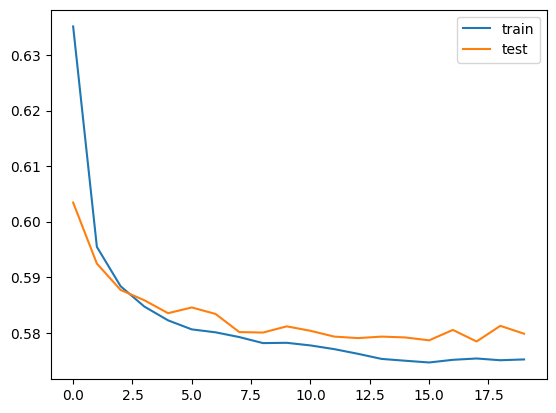

In [49]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()


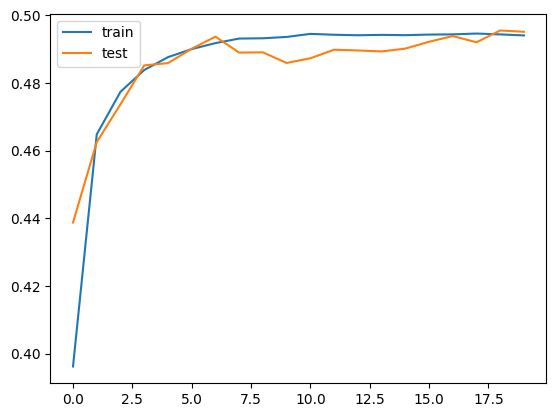

In [50]:

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()

In [51]:
def show_original_vs_decoded(dataset, model, n=10):
    for images, _ in dataset.take(4):  # Prend 1 batch
        decoded_images = model.predict(images)

        plt.figure(figsize=(15, 4))
        for i in range(n):
            # Image d'entrée
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(images[i].numpy())
            plt.title("Original")
            plt.axis("off")

            # Image décodée
            ax = plt.subplot(2, n, n + i + 1)
            plt.imshow(decoded_images[i])
            plt.title("Reconstruit")
            plt.axis("off")
        plt.tight_layout()
        plt.show()
        break  # une seule fois

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


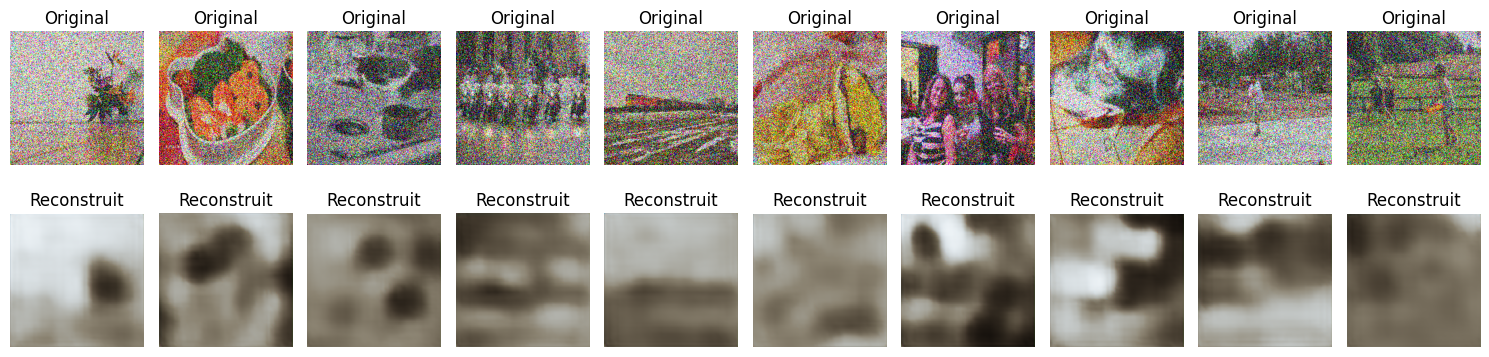

In [52]:
show_original_vs_decoded(noisy_val_ds, autoencoder)